# Stage 7, Part 2: Full MNIST Classification with PyTorch

**Goal:** now that you've built and debugged a 2-layer binary network entirely by hand, watch PyTorch automate that exact process — forward pass, backprop, parameter updates — then extend to full 10-digit classification and a CNN.

**Structure:** first, a feedforward network as close as possible to your Part 1 architecture (just multi-class instead of binary), so you can directly compare what PyTorch does automatically against what you wrote by hand. Then, a CNN — the architecture actually suited to image data.

## 1. Load MNIST via torchvision

**Syntax note:** `torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=...)` downloads MNIST directly (separate from Part 1's sklearn version, but same underlying data) and returns a PyTorch `Dataset` object. `transform=transforms.ToTensor()` converts each image from a PIL image into a PyTorch tensor AND automatically scales pixel values from 0-255 down to 0.0-1.0 — the same scaling you did manually in Part 1, now handled for you.

**Syntax note on DataLoader:** `DataLoader(dataset, batch_size=64, shuffle=True)` wraps a Dataset and automatically splits it into mini-batches for you. This is genuinely new: Part 1 used full-batch gradient descent (the ENTIRE training set every iteration). Mini-batch training computes gradients on a small random subset each step — faster per step, and the randomness often helps escape the kind of instability you fought with in Part 1.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Load MNIST training dataset
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

# Load MNIST test dataset
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

100.0%
100.0%
100.0%
100.0%


## 2. Build a feedforward network mirroring Part 1

**Syntax note:** in PyTorch, a network is a class inheriting from `nn.Module`. `__init__` defines the layers (as objects with their own learnable weights, which PyTorch tracks automatically), and `forward` defines how data flows through them — this is your `forward_propagation` function from Part 1, but you no longer manage `W`/`b` matrices by hand; `nn.Linear(in_features, out_features)` creates and owns them for you.

**Key architectural difference from Part 1, worth understanding before coding:** this is 10-class classification (which digit, 0-9), not binary. That means the output layer needs 10 neurons (one score per digit) instead of 1, and instead of sigmoid + binary cross-entropy, you'll use **softmax + categorical cross-entropy** — softmax turns 10 raw scores into a probability distribution across all 10 classes that sums to 1. Good news: PyTorch's `nn.CrossEntropyLoss` applies softmax internally, so your network's forward pass just outputs raw scores (called "logits") and never explicitly calls softmax itself.

In [32]:
class FeedforwardNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784,64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64,10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # 64 × 1 × 28 × 28 → 64 × 784
        x = self.fc1(x)            # 64 × 784 → 64 × 64
        x = self.relu(x)
        x = self.fc2(x)            # 64 × 64 → 64 × 10
        return x



## 3. Loss function and optimizer

**Syntax note:** `criterion = nn.CrossEntropyLoss()` — this is your `compute_cost` function from Part 1, generalized to multi-class and with softmax built in.

**Syntax note:** `optimizer = optim.SGD(model.parameters(), lr=0.01)` — this replaces your manual `W = W - learning_rate * dW` lines. `model.parameters()` gives the optimizer access to every learnable weight in your network automatically (no manually tracking W1, b1, W2, b2 separately), and calling `optimizer.step()` later will apply the update to all of them at once.

In [33]:
# TODO: model = FeedforwardNet()
# TODO: criterion = nn.CrossEntropyLoss()
# TODO: optimizer = optim.SGD(model.parameters(), lr=0.01)
model = FeedforwardNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


## 4. The training loop — watch what gets automated

Compare each line here to what you wrote by hand in Part 1:

```python
for epoch in range(n_epochs):
    for images, labels in train_loader:
        optimizer.zero_grad()          # clear old gradients (PyTorch accumulates them otherwise)
        outputs = model(images)         # forward pass -- same as your Z1/A1/Z2/A2 computation
        loss = criterion(outputs, labels)  # same as your compute_cost
        loss.backward()                 # THIS is your entire backward_propagation function, automated
        optimizer.step()                # THIS is your four W/b update lines, automated
```

**Syntax note on `loss.backward()`:** this single call computes the gradient of the loss with respect to EVERY parameter in the network, using the exact same chain rule mechanics you derived and implemented by hand in Part 1 — PyTorch just tracks the computation graph automatically (called "autograd") and works backward through it for you. This should not feel like magic anymore — you know exactly what it's doing internally.

**Syntax note on `optimizer.zero_grad()`:** PyTorch accumulates (adds to) gradients by default rather than replacing them each time, which is useful in some advanced scenarios but NOT what you want in a normal loop — forgetting this line is one of the most common PyTorch bugs, since it silently causes gradients from previous batches to keep piling up.

In [41]:
n_epochs = 5
loss_history = []

# TODO: implement the training loop shown above, appending loss.item() to loss_history each batch (or each epoch's average)

for epoch in range(n_epochs):

    for images, labels in train_loader:

        # 1. Clear gradients from the previous iteration
        print(model.fc1.weight.grad)
        optimizer.zero_grad()
        print(model.fc1.weight.grad)

        # 2. Forward pass:
        #    Feed images through the neural network
        #    outputs = the model's predictions (10 scores per image)
        outputs = model(images)

        # 3. Calculate how wrong the predictions are
        loss = criterion(outputs, labels)

        # 4. Save the numerical loss for plotting later
        loss_history.append(loss.item())

        # 5. Backpropagation:
        #    Calculate the gradient of the loss with respect to
        #    every learnable parameter in the model
        loss.backward()

        # 6. Update the weights using those gradients
        optimizer.step()



tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -1.9936e-03,
         -3.9752e-04, -1.9211e-04],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  3.4277e-03,
          4.3362e-04,  4.5831e-04],
        ...,
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -4.1640e-04,
         -1.2273e-04, -7.3445e-05],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -7.0215e-04,
         -7.3564e-05, -5.2702e-05],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -1.2340e-03,
         -1.5297e-04, -1.0444e-04]])
tensor([[ 0.0000,  0.0000,  0.0000,  ..., -0.0025, -0.0006, -0.0003],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ..., -0.0024,  0.0021, -0.0004],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0020,  0.0009,  0.0007],
        [ 0.0000,  0.0000,  0.0000,  ..., -0.0004, -0.0002, -0.0001],
     

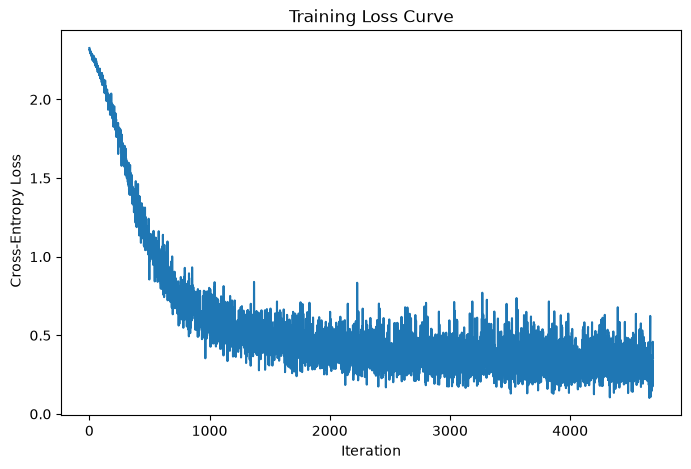

In [35]:
# TODO: plot loss_history -- same sanity check as every from-scratch model so far

# Plot the loss curve
plt.figure(figsize=(8, 5))
nn_loss_history = loss_history
plt.plot(loss_history)

plt.xlabel("Iteration")
plt.ylabel(" Cross-Entropy Loss")
plt.title("Training Loss Curve")

plt.show()




## 5. Evaluate the feedforward network

**Syntax note:** wrap evaluation in `with torch.no_grad():` — this tells PyTorch not to bother tracking gradients during evaluation, since you're not training. Skipping this doesn't break anything, but wastes memory and computation.

**Syntax note:** `torch.argmax(outputs, dim=1)` converts the 10 raw class scores per image into a single predicted digit — the index of the highest score. This is the multi-class equivalent of your Part 1 `(A2 >= 0.5)` threshold step.

In [36]:
# TODO: loop through test_loader with torch.no_grad(), get predictions via argmax, compute overall accuracy
# (accuracy alone is fine here -- MNIST's 10 classes are roughly balanced, unlike your imbalanced Stage 6 projects)
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("Accuracy:", accuracy)

Accuracy: 0.914


## 6. Build a CNN

A plain feedforward network treats each pixel as an independent feature, ignoring that nearby pixels are spatially related. A CNN exploits that structure directly using convolutional layers — small filters that slide across the image detecting local patterns (edges, curves), followed by pooling layers that downsample while keeping the strongest signals.

**Syntax note:** `nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)` — slides 16 different 3x3 filters across the image, each learning to detect a different local pattern. `in_channels=1` because MNIST images are grayscale (1 channel; a color image would be 3). `nn.MaxPool2d(kernel_size=2)` then downsamples by taking the max value in each 2x2 region, shrinking the spatial size while keeping the strongest activations.

Guiding question: given what you know about parameter counts from Part 1 (`W1` alone was 784 × 64 = 50,176 parameters), why might a convolutional filter — reused across the ENTIRE image rather than having separate weights per pixel position — use dramatically fewer parameters?

In [37]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128) # -- after 2 pooling layers, 28x28 has shrunk to 7x7
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        

    def forward(self, x): 
        x = self.relu(self.conv1(x))     #Conv + ReLU
        x = self.pool(x)                 # Pooling #1: 28×28 → 14×14

        x = self.relu(self.conv2(x))     #Conv + ReLU
        x = self.pool(x)                 # Pooling #2: 14×14 → 7×7

        x = x.view(x.size(0), -1)        #Flatten
        x = self.relu(self.fc1(x))       #FC layers
        x = self.fc2(x)

        return x


## 7. Train and evaluate the CNN

Same training loop shape as Section 4 — literally reusable, just swap which model you instantiate. This is worth noticing: PyTorch's training loop doesn't care about your architecture at all, it just calls `.backward()` and `.step()` regardless of what's inside `model`.

In [38]:
# TODO: model = CNN(), same criterion/optimizer setup, same training loop, same evaluation as Sections 3-5

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

n_epochs = 5
loss_history = []
for epoch in range(n_epochs):

    for images, labels in train_loader:

        # 1. Clear gradients from the previous iteration
        optimizer.zero_grad()

        # 2. Forward pass:
        #    Feed images through the neural network
        #    outputs = the model's predictions (10 scores per image)
        outputs = model(images)

        # 3. Calculate how wrong the predictions are
        loss = criterion(outputs, labels)

        # 4. Save the numerical loss for plotting later
        loss_history.append(loss.item())

        # 5. Backpropagation:
        #    Calculate the gradient of the loss with respect to
        #    every learnable parameter in the model
        loss.backward()

        # 6. Update the weights using those gradients
        optimizer.step()



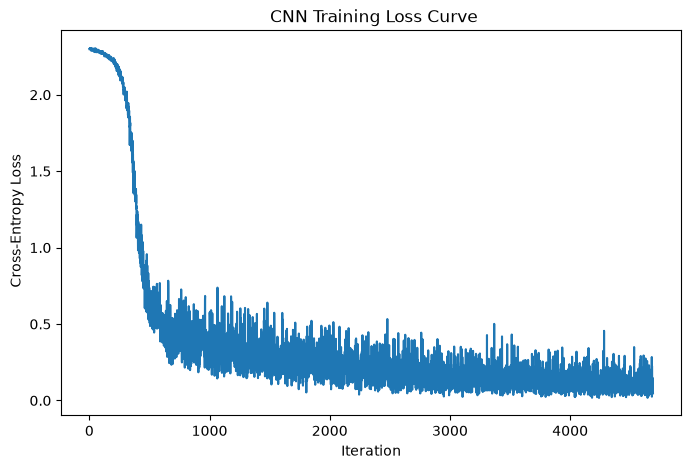

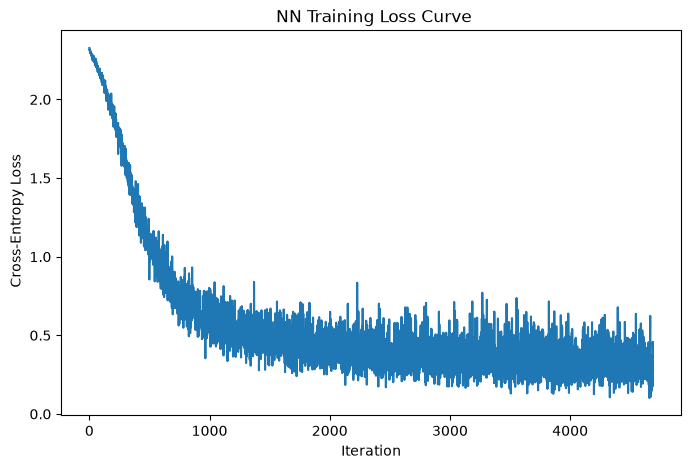

In [39]:
# TODO: plot loss_history -- same sanity check as every from-scratch model so far

# Plot the loss curve
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Iteration")
plt.ylabel(" Cross-Entropy Loss")
plt.title(" CNN Training Loss Curve")

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(nn_loss_history)

plt.xlabel("Iteration")
plt.ylabel(" Cross-Entropy Loss")
plt.title(" NN Training Loss Curve")

plt.show()





In [40]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

cnn_accuracy = correct / total
print("CNN Accuracy:", cnn_accuracy)

CNN Accuracy: 0.9684


## 8. Compare feedforward vs. CNN

Guiding questions:
- Which model achieved higher test accuracy?
- Which trained faster per epoch, and why might that be (think about parameter count from Section 6's guiding question)?
- Was the accuracy gap large or small? Given MNIST is a relatively "easy" image dataset (clean, centered, single-channel digits), would you expect the CNN's advantage to be even larger on a harder dataset like CIFAR-10 (color photos of real objects)?

- The CNN model achieved higher test accuracy at 96.8% vs 91.4%.
- The NN trained faster per epoch and that is genuinely because the NN had fewer paremeters ( weights ) going from one layer to the next compared to the CNN. 
    convolution is computationally more expensive per parameter than a plain matrix multiply. A Linear layer computes one big matrix multiplication in a single efficient operation.
    A Conv2d layer has to slide each filter across every spatial position in the image, which is inherently more sequential/expensive computation for the same parameter, even when 
    the total weight count is similar or smaller.
- The accuracy gap was not that large but given the therotical standpoint of a CNN, the CNN has a huge advantage on a harder dataset like CIFAR-10 compared to the NN
because of the fact that it can exploit spatial data.

## Wrap-up

Write a short summary:
- Map each line of PyTorch's training loop (`optimizer.zero_grad()`, `loss.backward()`, `optimizer.step()`) back to the specific code you wrote by hand in Part 1. Be concrete.
- Now that you've seen both, do you think starting with the from-scratch NumPy version before PyTorch was worth the extra effort? What would have been different if you'd started here instead?
- What's still true about training a neural network regardless of whether you write it by hand or use a framework — what hasn't changed since your very first linear regression notebook in Stage 4?

- optmizer.zero_grad() = each iteration's gradients were always freshly computed with no memory of the previous one.
- loss.backward() = dW1, db1, dW2, db2 = backward_propagation(X, y, A2, Z1, A1, Z2, W2)
- optimizer.step() =         
        #update
        W2 = W2 - learning_rate * (dW2)
        b2 = b2 - learning_rate * (db2)
        
        W1 = W1 - learning_rate * (dW1)
        b1 = b1 - learning_rate * (db1)



- Starting from the NumPy version enabled me to understand the limiations numpy had in deep learning models, using pytorch genuinely enables more complex predictions. Additionally, starting with the numpy version allowed me to understand the basics of NN with implementing forward and backward propagation on my own without relying on internal methods from the Pytorch framework. In conclusion the Pytorch automated the steamline vs numpy handwritten functions.

- What is true about training a neural network regardless of its by hand or framework is that the pipeline stays the same, gather the data -> forward pass, back propagation, compute cost, and update the weights. This pipeline is at the heart of any neural network.